<a href="https://colab.research.google.com/github/TiaGolyan2508/python-/blob/main/brainTumorSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required libraries for medical image processing
# nibabel -> used to read MRI files (.nii/.nii.gz)
# monai -> medical imaging deep learning toolkit
# grad-cam -> for explainable AI visualization
!pip install nibabel
!pip install monai
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.9 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import important libraries

import torch                     # PyTorch deep learning framework
import torch.nn as nn            # neural network layers
import numpy as np               # numerical operations
import nibabel as nib            # to load MRI files
import matplotlib.pyplot as plt  # visualization
from torch.utils.data import Dataset, DataLoader

In [7]:
!ls /content/drive/MyDrive/

 BraTS	'Colab Notebooks'  'Memories '


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!ls /content/drive/MyDrive/

 BraTS	'Colab Notebooks'  'Memories '


In [10]:
!ls /content/drive/MyDrive/BraTS/

In [12]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tiya2508","key":"6f413a343154b5994bc4a0da920d3d28"}'}

In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.15G/4.16G [00:42<00:00, 29.4MB/s]
100% 4.16G/4.16G [00:43<00:00, 104MB/s] 


In [17]:
!unzip brats20-dataset-training-validation.zip -d /content/brats

Archive:  brats20-dataset-training-validation.zip
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_seg.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_flair.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_seg.nii  
  inflating: /co

In [18]:
!ls /content/brats

BraTS2020_TrainingData	BraTS2020_ValidationData


In [19]:
!ls /content/brats/BraTS2020_TrainingData

MICCAI_BraTS2020_TrainingData


In [20]:
!ls /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData

BraTS20_Training_001  BraTS20_Training_125  BraTS20_Training_249
BraTS20_Training_002  BraTS20_Training_126  BraTS20_Training_250
BraTS20_Training_003  BraTS20_Training_127  BraTS20_Training_251
BraTS20_Training_004  BraTS20_Training_128  BraTS20_Training_252
BraTS20_Training_005  BraTS20_Training_129  BraTS20_Training_253
BraTS20_Training_006  BraTS20_Training_130  BraTS20_Training_254
BraTS20_Training_007  BraTS20_Training_131  BraTS20_Training_255
BraTS20_Training_008  BraTS20_Training_132  BraTS20_Training_256
BraTS20_Training_009  BraTS20_Training_133  BraTS20_Training_257
BraTS20_Training_010  BraTS20_Training_134  BraTS20_Training_258
BraTS20_Training_011  BraTS20_Training_135  BraTS20_Training_259
BraTS20_Training_012  BraTS20_Training_136  BraTS20_Training_260
BraTS20_Training_013  BraTS20_Training_137  BraTS20_Training_261
BraTS20_Training_014  BraTS20_Training_138  BraTS20_Training_262
BraTS20_Training_015  BraTS20_Training_139  BraTS20_Training_263
BraTS20_Training_016  Bra

In [21]:
data_dir = "/content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

In [22]:
import os

patients = [os.path.join(data_dir, p) for p in os.listdir(data_dir)]

print("Total patients:", len(patients))

Total patients: 371


In [23]:
patients = patients[:20]

In [25]:
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np
import os

class BraTSDataset(Dataset):

    """
    Custom PyTorch Dataset for BraTS MRI data.

    Each patient folder contains:
    T1, T2, T1ce, FLAIR MRI modalities + tumor segmentation mask.

    We convert 3D MRI volumes into multiple 2D slices for training.
    """

    def __init__(self, patient_dirs):

        self.samples = []

        # Loop through each patient folder
        for patient in patient_dirs:

            patient_id = os.path.basename(patient)

            # Construct file paths for all modalities
            t1_path = os.path.join(patient, patient_id + "_t1.nii")
            t2_path = os.path.join(patient, patient_id + "_t2.nii")
            t1ce_path = os.path.join(patient, patient_id + "_t1ce.nii")
            flair_path = os.path.join(patient, patient_id + "_flair.nii")
            seg_path = os.path.join(patient, patient_id + "_seg.nii")

            # Load MRI volumes
            t1 = nib.load(t1_path).get_fdata()
            t2 = nib.load(t2_path).get_fdata()
            t1ce = nib.load(t1ce_path).get_fdata()
            flair = nib.load(flair_path).get_fdata()
            seg = nib.load(seg_path).get_fdata()

            # Convert 3D volume into 2D slices
            for i in range(t1.shape[2]):

                image = np.stack([
                    t1[:, :, i],
                    t2[:, :, i],
                    t1ce[:, :, i],
                    flair[:, :, i]
                ], axis=0)

                mask = seg[:, :, i]

                self.samples.append((image, mask))

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image, mask = self.samples[idx]

        image = torch.tensor(image).float()
        mask = torch.tensor(mask).float().unsqueeze(0)

        return image, mask

In [26]:
dataset = BraTSDataset(patients)

print("Total training slices:", len(dataset))

Total training slices: 3100


In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [28]:
# Use only first 10 patients for faster demo training
patients = patients[:10]

print("Using patients:", len(patients))

Using patients: 10


In [29]:
# Create dataset object
dataset = BraTSDataset(patients)

print("Total slices available:", len(dataset))

Total slices available: 1550


In [30]:
from torch.utils.data import DataLoader

# DataLoader loads images in batches during training
train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- Novelty Module: Dynamic Modality Reliability ----
class ModalityReliability(nn.Module):
    """
    Learns which MRI modality (T1, T2, T1ce, FLAIR) is most useful
    and weights them dynamically.
    """
    def __init__(self, channels=4):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        weights = self.sigmoid(self.conv(x))
        return x * weights


# ---- Basic U-Net Convolution Block ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ---- Attention Gate (focus on tumor regions) ----
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.psi(F.relu(g1 + x1))
        return x * psi


# ---- Full Segmentation Model ----
class BrainTumorSegmentationModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Novelty block
        self.modality_attention = ModalityReliability()

        # Encoder
        self.conv1 = DoubleConv(4, 64)
        self.pool = nn.MaxPool2d(2)

        self.conv2 = DoubleConv(64,128)

        # Decoder
        self.up = nn.ConvTranspose2d(128,64,2,stride=2)

        self.att = AttentionBlock(64,64,32)

        self.conv3 = DoubleConv(128,64)

        # Output segmentation mask
        self.out = nn.Conv2d(64,1,1)

    def forward(self, x):

        # Modality weighting
        x = self.modality_attention(x)

        # Encoder
        e1 = self.conv1(x)
        e2 = self.conv2(self.pool(e1))

        # Decoder
        d1 = self.up(e2)

        # Attention skip connection
        e1_att = self.att(d1,e1)

        d1 = torch.cat([d1,e1_att],dim=1)

        d1 = self.conv3(d1)

        return torch.sigmoid(self.out(d1))

In [33]:
def dice_loss(pred, target):

    smooth = 1

    intersection = (pred * target).sum()

    return 1 - ((2 * intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = BrainTumorSegmentationModel().to(device)

Using device: cuda


In [35]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [36]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

Epoch: 1 Loss: 0.9030315471985906
Epoch: 2 Loss: 0.8488445755132695
Epoch: 3 Loss: 0.7704150483165819
Epoch: 4 Loss: 0.674187155267627
Epoch: 5 Loss: 0.5873700355746082


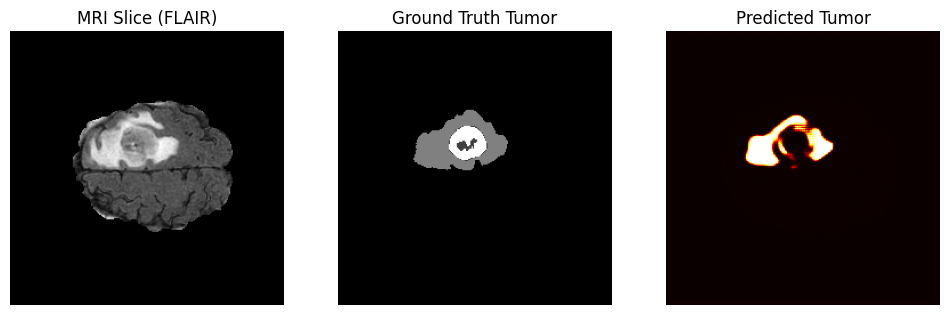

In [37]:
# Get a batch of images from dataloader
images, masks = next(iter(train_loader))

# Move to GPU
images = images.to(device)

# Disable gradient calculation
with torch.no_grad():
    preds = model(images)

# Convert tensors to numpy for visualization
pred = preds[0].cpu().numpy()[0]
gt = masks[0].numpy()[0]
mri = images[0][3].cpu().numpy()   # using FLAIR slice for visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Original MRI
plt.subplot(1,3,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI Slice (FLAIR)")
plt.axis("off")

# Ground truth
plt.subplot(1,3,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth Tumor")
plt.axis("off")

# Predicted segmentation
plt.subplot(1,3,3)
plt.imshow(pred, cmap="hot")
plt.title("Predicted Tumor")
plt.axis("off")

plt.show()

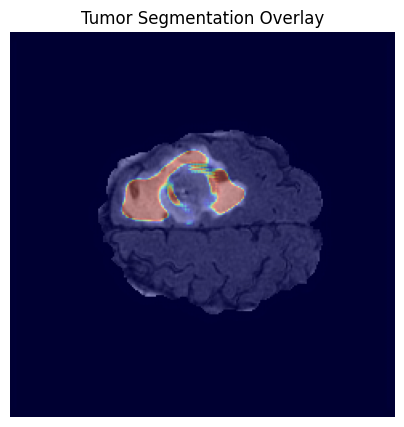

In [38]:
plt.figure(figsize=(5,5))

plt.imshow(mri, cmap="gray")
plt.imshow(pred, cmap="jet", alpha=0.4)

plt.title("Tumor Segmentation Overlay")
plt.axis("off")

plt.show()

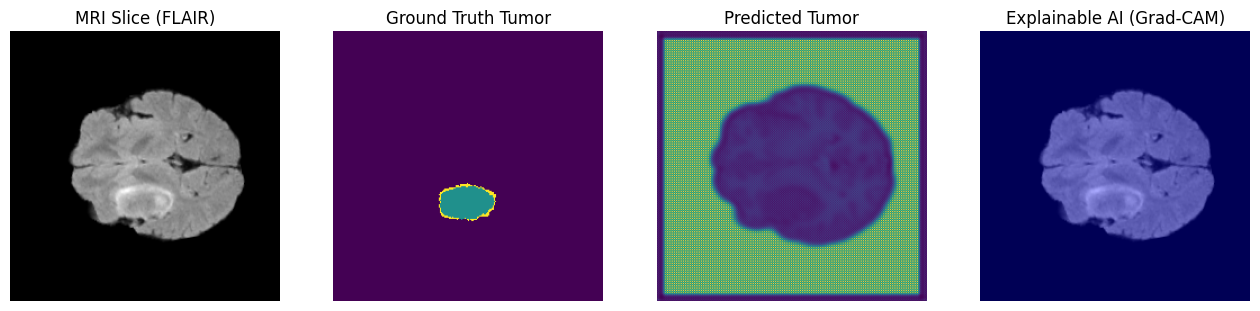

In [41]:
# ==============================
# Explainable AI Visualization
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget


# Get one batch
images, masks = next(iter(train_loader))
images = images.to(device)

# Run model prediction
with torch.no_grad():
    preds = model(images)

# Extract first sample
pred = preds[0].cpu().numpy()[0]
gt = masks[0].numpy()[0]
mri = images[0][3].cpu().numpy()   # FLAIR slice


# Normalize MRI
mri_norm = (mri - mri.min()) / (mri.max() - mri.min())

# Convert grayscale MRI to RGB
mri_rgb = np.repeat(mri_norm[:, :, np.newaxis], 3, axis=2)


# Create Grad-CAM target mask
target_mask = pred > 0.5
targets = [SemanticSegmentationTarget(0, target_mask)]


# Select layer for Grad-CAM
target_layers = [model.conv3.conv[-1]]


# Generate Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

grayscale_cam = cam(input_tensor=images, targets=targets)

cam_map = grayscale_cam[0]


# Overlay Grad-CAM heatmap on MRI
overlay = show_cam_on_image(mri_rgb, cam_map, use_rgb=True)


# ==============================
# Visualization for PPT
# ==============================

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI Slice (FLAIR)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt)
plt.title("Ground Truth Tumor")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred)
plt.title("Predicted Tumor")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Explainable AI (Grad-CAM)")
plt.axis("off")

plt.show()